
---

# 🎚️ **`Feature Scaling: Standardization vs. Normalization in Python for Machine Learning`** 📊  

Feature scaling is an essential preprocessing step in **Machine Learning (ML)** that ensures numerical data is on a comparable scale, improving **model performance** and **convergence speed**. Two commonly used methods for feature scaling are:

1. **Standardization (Z-score normalization)**
2. **Normalization (Min-Max scaling)**

---

## ✅ **1. Why is Feature Scaling Important?**  

✔ **Prevents dominance of large-magnitude features**  
✔ **Improves convergence in gradient-based models** (e.g., Logistic Regression, Neural Networks)  
✔ **Ensures fair distance calculations** for distance-based models (**KNN, SVM, K-Means**)  
✔ **Reduces numerical instability** in ML algorithms  

---

## 📊 **2. Standardization (Z-score Normalization)**  

**Formula:**  
$$
X' = \frac{X - \mu}{\sigma}
$$
Where:  
- $ \mu $ = Mean of the feature  
- $ \sigma $ = Standard deviation of the feature  

### 🔹 **Key Characteristics of Standardization**  
✅ **Centers data** around **mean = 0** with **standard deviation = 1**  
✅ **Retains original feature distribution** (useful for normally distributed data)  
✅ **Works well for algorithms that assume normality** (e.g., **Logistic Regression, PCA, SVM**)  
✅ **Not affected by outliers** as much as Min-Max Scaling  

### ✍️ **Example: Applying Standardization in Python**  


In [9]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Sample Data
df = pd.DataFrame({'Age': [22, 25, 47, 35, 50], 'Salary': [20000, 30000, 50000, 40000, 70000]})

# Apply Standardization
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\nNon-Standardized Data:\n", df)
print("*"*40)
print("\nStandardized Data:\n", df_standardized)



Non-Standardized Data:
    Age  Salary
0   22   20000
1   25   30000
2   47   50000
3   35   40000
4   50   70000
****************************************

Standardized Data:
         Age    Salary
0 -1.224745 -1.278724
1 -0.958496 -0.697486
2  0.993996  0.464991
3 -0.071000 -0.116248
4  1.260245  1.627467



---

## 📊 **3. Normalization (Min-Max Scaling)**  

**Formula:**  
$$
X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

Where:  
- $ X_{\min} $ and $X_{\max}$ are the minimum and maximum values of the feature.

### 🔹 **Key Characteristics of Normalization**  
✅ **Scales features to a fixed range** (usually **[0,1]** or **[-1,1]**)  
✅ **Sensitive to outliers** (as it depends on min/max values)  
✅ **Preferred for deep learning models** (Neural Networks)  
✅ **Good for algorithms that use Euclidean distance** (e.g., **KNN, K-Means**)  

### ✍️ **Example: Applying Min-Max Normalization in Python**  

In [2]:

from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\nMin-Max Normalized Data:\n", df_normalized)



Min-Max Normalized Data:
         Age  Salary
0  0.000000     0.0
1  0.107143     0.2
2  0.892857     0.6
3  0.464286     0.4
4  1.000000     1.0


---

## 📉 **4. Comparing Standardization vs. Normalization**  

| **Feature**              | **Standardization (Z-score)** | **Normalization (Min-Max Scaling)** |
|--------------------------|------------------------------|-------------------------------------|
| **Formula**              | $X' = \frac{X - \mu}{\sigma} $ | $ X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}} $ |
| **Resulting Range**      | Mean = 0, Std Dev = 1        | Scales between **[0,1]** (or custom range) |
| **Effect on Outliers**   | Less sensitive to outliers   | Strongly affected by outliers |
| **When to Use**          | When data follows a **normal distribution** | When features have **different ranges** |
| **Best For**             | **PCA, Logistic Regression, SVM, Linear Models** | **KNN, Neural Networks, K-Means, Deep Learning** |

---

## 📊 **5. Visualizing the Effect of Scaling**  

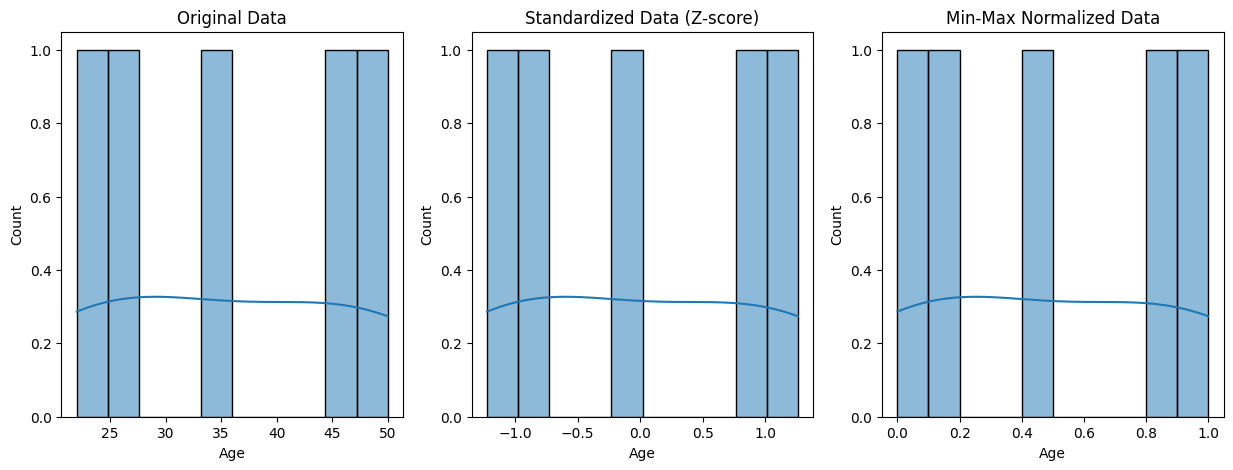

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns

# Combine Original, Standardized, and Normalized Data
df_scaled = pd.concat([df, df_standardized, df_normalized], axis=1)
df_scaled.columns = ['Age', 'Salary', 'Age_Standardized', 'Salary_Standardized', 'Age_Normalized', 'Salary_Normalized']

# Plot the distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Age'], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Original Data")

sns.histplot(df_standardized['Age'], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Standardized Data (Z-score)")

sns.histplot(df_normalized['Age'], bins=10, kde=True, ax=axes[2])
axes[2].set_title("Min-Max Normalized Data")

plt.show()


---

## 🎯 **6. When to Use Standardization vs. Normalization?**  

| **Scenario**                           | **Recommended Scaling Method** |
|-----------------------------------------|--------------------------------|
| **Features have different units (e.g., Age in years, Salary in $)** | **Min-Max Scaling (Normalization)** |
| **Data is normally distributed**       | **Standardization (Z-score)** |
| **Outliers present in data**           | **Standardization** (Z-score is robust to outliers) |
| **Deep Learning (Neural Networks)**    | **Normalization (0 to 1 range)** |
| **PCA (Principal Component Analysis)** | **Standardization (ensures equal variance)** |
| **Distance-based algorithms (KNN, K-Means, SVM)** | **Normalization (0 to 1 range)** |
| **Logistic Regression, Linear Regression** | **Standardization** |

---

## 🏹 **7. Feature Scaling in a Machine Learning Pipeline**  

### ✅ **Example: Using Feature Scaling in an ML Model (Random Forest Example)**  

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Sample Dataset
df = pd.DataFrame({'Age': [22, 25, 47, 35, 50], 'Salary': [20000, 30000, 50000, 40000, 70000], 'Target': [0, 1, 1, 0, 1]})

# Split Data
X = df[['Age', 'Salary']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Pipeline with Scaling & Model
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Try MinMaxScaler for Normalization
    ('classifier', RandomForestClassifier(n_estimators=100))
])

# Train Model
pipeline.fit(X_train, y_train)

# Predict & Evaluate
accuracy = pipeline.score(X_test, y_test)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.0


---

## 🏆 **8. Final Thoughts**  

✔ **Standardization (Z-score)** is best when **data follows a normal distribution** and works well with **Logistic Regression, SVM, and PCA**.  
✔ **Normalization (Min-Max Scaling)** is best when **data varies across different ranges** and is ideal for **Neural Networks, KNN, and K-Means**.  
✔ Always **analyze data distribution before choosing a scaling method**.  
✔ Use **Pipelines** to integrate feature scaling and model training **seamlessly**.  

💡 **Pro Tip:** Always apply scaling **after** splitting data into train-test sets to avoid **data leakage**.

---